# Neural Networks for Time Series Classification

In [2]:
#Importing necessary libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

import torch
import tensorflow as tf

from tensorflow.keras import layers, models, callbacks, regularizers

from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix
)

from sklearn.utils.class_weight import compute_class_weight
SEED = 42

np.random.seed(SEED)
tf.random.set_seed(SEED)
tf.keras.utils.set_random_seed(SEED)

## Import tensors

In [3]:
#Load tensors
from pathlib import Path

TENSOR_DIR = Path("/Users/omarleosamman/Downloads/pfizer_tensors")

X_tensor = torch.load(TENSOR_DIR / "X_features.pt")
y_tensor = torch.load(TENSOR_DIR / "y_labels.pt")
fold_tensor = torch.load(TENSOR_DIR / "folds.pt")

print("X:", X_tensor.shape)
print("y:", y_tensor.shape)
print("folds:", fold_tensor.shape)

X: torch.Size([20931, 86, 65])
y: torch.Size([20931])
folds: torch.Size([20931])


In [4]:
# Convert to TensorFlow tensors
X_tf = tf.convert_to_tensor(X_tensor.numpy(), dtype=tf.float32)
y_tf = tf.convert_to_tensor(y_tensor.numpy(), dtype=tf.int64)
fold_tf = tf.convert_to_tensor(fold_tensor.cpu().numpy(), dtype=tf.int64)

print(X_tf.shape)
print(y_tf.shape)
print(fold_tf.shape)

(20931, 86, 65)
(20931,)
(20931,)


In [5]:
# Analyze class distribution
unique_labels, label_counts = np.unique(y_tf.numpy(), return_counts=True)

pd.DataFrame({
    "label": unique_labels,
    "count": label_counts
})

,label,count
0,-1,9032
1,0,6406
2,1,3349
3,2,2144


In [6]:
# Define label names for better visualization
label_names = {
    0: "SEG_A",
    1: "SEG_B",
    2: "SEG_C"
}

target_names = ["SEG_A", "SEG_B", "SEG_C"]

In [7]:
# Filter out unlabeled samples (label = -1)
labeled_mask = y_tf != -1

X_labeled = tf.boolean_mask(X_tf, labeled_mask)
y_labeled = tf.boolean_mask(y_tf, labeled_mask)
fold_labeled = tf.boolean_mask(fold_tf, labeled_mask)

print("Labeled tensors:")
print("X_labeled:", X_labeled.shape)
print("y_labeled:", y_labeled.shape)
print("fold_labeled:", fold_labeled.shape)

Labeled tensors:
X_labeled: (11899, 86, 65)
y_labeled: (11899,)
fold_labeled: (11899,)


In [8]:
# Analyze class distribution in labeled samples
unique_labeled, counts_labeled = np.unique(y_labeled.numpy(), return_counts=True)

class_dist = pd.DataFrame({
    "class": [label_names[i] for i in unique_labeled],
    "count": counts_labeled,
    "pct": counts_labeled / counts_labeled.sum() * 100
})

class_dist

,class,count,pct
0,SEG_A,6406,53.836457
1,SEG_B,3349,28.145222
2,SEG_C,2144,18.018321


In [9]:
# Analyze fold distribution in labeled samples
fold_values, fold_counts = np.unique(fold_labeled.numpy(), return_counts=True)

pd.DataFrame({
    "fold": fold_values,
    "count": fold_counts
})

,fold,count
0,0,2380
1,1,2380
2,2,2380
3,3,2380
4,4,2379


## Fold assignment

In [10]:
fold_class_dist = pd.DataFrame({
    "fold": fold_labeled.numpy(),
    "label": y_labeled.numpy()
})

fold_class_table = pd.crosstab(
    fold_class_dist["fold"],
    fold_class_dist["label"],
    normalize="index"
)

fold_class_table.columns = ["SEG_A", "SEG_B", "SEG_C"]
fold_class_table

,SEG_A,SEG_B,SEG_C
fold,,,
0,0.538655,0.281092,0.180252
1,0.538235,0.281513,0.180252
2,0.538235,0.281513,0.180252
3,0.538235,0.281513,0.180252
4,0.538462,0.281631,0.179908


In [11]:
all_folds = sorted(np.unique(fold_labeled.numpy()))
all_folds = [f for f in all_folds if f != -1]

all_folds

[np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4)]

In [12]:
# Define fold assignments for train/val/test split
test_fold = 3
val_fold = 4

# Create boolean masks for train/val/test splits
train_mask = (fold_labeled != test_fold) & (fold_labeled != val_fold)
val_mask = fold_labeled == val_fold
test_mask = fold_labeled == test_fold

X_train = tf.boolean_mask(X_labeled, train_mask)
y_train = tf.boolean_mask(y_labeled, train_mask)

X_val = tf.boolean_mask(X_labeled, val_mask)
y_val = tf.boolean_mask(y_labeled, val_mask)

X_test = tf.boolean_mask(X_labeled, test_mask)
y_test = tf.boolean_mask(y_labeled, test_mask)

print("Train:", X_train.shape, y_train.shape)
print("Val:", X_val.shape, y_val.shape)
print("Test:", X_test.shape, y_test.shape)

Train: (7140, 86, 65) (7140,)
Val: (2379, 86, 65) (2379,)
Test: (2380, 86, 65) (2380,)


In [13]:
# Function to show class distribution for a given tensor
def show_class_distribution_tf(y_tensor, name):
    y_np = y_tensor.numpy()
    labels, counts = np.unique(y_np, return_counts=True)
    
    df_dist = pd.DataFrame({
        "class": [label_names[i] for i in labels],
        "count": counts,
        "pct": np.round(counts / counts.sum() * 100, 2)
    })
    
    print(name)
    display(df_dist)

show_class_distribution_tf(y_train, "Train distribution")
show_class_distribution_tf(y_val, "Validation distribution")
show_class_distribution_tf(y_test, "Test distribution")

Train distribution


,class,count,pct
0,SEG_A,3844,53.84
1,SEG_B,2009,28.14
2,SEG_C,1287,18.03


Validation distribution


,class,count,pct
0,SEG_A,1281,53.85
1,SEG_B,670,28.16
2,SEG_C,428,17.99


Test distribution


,class,count,pct
0,SEG_A,1281,53.82
1,SEG_B,670,28.15
2,SEG_C,429,18.03


In [14]:
# Compute class weights for imbalanced training data
y_train_np = y_train.numpy()

classes = np.unique(y_train_np)

weights = compute_class_weight(
    class_weight="balanced",
    classes=classes,
    y=y_train_np
)

class_weight = dict(zip(classes, weights))

class_weight

{np.int64(0): np.float64(0.619146722164412),
 np.int64(1): np.float64(1.1846689895470384),
 np.int64(2): np.float64(1.8492618492618493)}

In [15]:
class_weight_soft = {
    0: 1.0,  # SEG_A
    1: 1.1,  # SEG_B
    2: 1.3   # SEG_C
}

In [16]:
# Print dataset dimensions and number of classes
n_weeks = X_train.shape[1]
n_features = X_train.shape[2]
n_classes = len(target_names)

print("n_weeks:", n_weeks)
print("n_features:", n_features)
print("n_classes:", n_classes)

n_weeks: 86
n_features: 65
n_classes: 3


## Model evaluation and history visualization functions

In [17]:
def plot_confusion_matrix_with_percentages(
    y_true,
    y_pred,
    target_names,
    normalize=True,
    title="Confusion Matrix"
):
    cm = confusion_matrix(y_true, y_pred)
    
    if normalize:
        cm_display = cm / cm.sum(axis=1, keepdims=True)
    else:
        cm_display = cm

    plt.figure(figsize=(7, 5))
    plt.imshow(cm_display, aspect="auto")
    plt.colorbar()

    plt.xticks(range(len(target_names)), target_names, rotation=45)
    plt.yticks(range(len(target_names)), target_names)

    plt.title(title)
    plt.xlabel("Predicted")
    plt.ylabel("Actual")

    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            if normalize:
                text = f"{cm_display[i, j]*100:.1f}%\n({cm[i, j]})"
            else:
                text = f"{cm[i, j]}"
            
            plt.text(
                j,
                i,
                text,
                ha="center",
                va="center"
            )

    plt.tight_layout()
    plt.show()

    return pd.DataFrame(cm, index=target_names, columns=target_names)

In [18]:
# Function to evaluate Keras model performance
def evaluate_keras_model(model, X_test, y_test, target_names, title="Model"):
    proba = model.predict(X_test)
    y_pred = np.argmax(proba, axis=1)
    
    y_true = y_test.numpy()
    
    acc = accuracy_score(y_true, y_pred)
    macro_f1 = f1_score(y_true, y_pred, average="macro")
    weighted_f1 = f1_score(y_true, y_pred, average="weighted")
    
    print("Accuracy:", acc)
    print("Macro F1:", macro_f1)
    print("Weighted F1:", weighted_f1)
    print()
    print(classification_report(y_true, y_pred, target_names=target_names))
    
    cm_df = plot_confusion_matrix_with_percentages(
        y_true=y_true,
        y_pred=y_pred,
        target_names=target_names,
        normalize=True,
        title=f"Normalized Confusion Matrix - {title}"
    )
    
    return {
        "accuracy": acc,
        "macro_f1": macro_f1,
        "weighted_f1": weighted_f1,
        "y_pred": y_pred,
        "proba": proba,
        "cm": cm_df
    }

In [19]:
# Function to plot training history
def plot_history(history, title):
    hist = pd.DataFrame(history.history)
    
    plt.figure(figsize=(8, 4))
    plt.plot(hist["loss"], label="train_loss")
    plt.plot(hist["val_loss"], label="val_loss")
    plt.title(f"{title} - Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()
    plt.show()
    
    plt.figure(figsize=(8, 4))
    plt.plot(hist["accuracy"], label="train_accuracy")
    plt.plot(hist["val_accuracy"], label="val_accuracy")
    plt.title(f"{title} - Accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.legend()
    plt.show()

In [20]:
def sparse_categorical_focal_loss(gamma=2.0, alpha=None):
    def loss_fn(y_true, y_pred):
        y_true = tf.cast(y_true, tf.int32)
        y_true_one_hot = tf.one_hot(y_true, depth=tf.shape(y_pred)[-1])
        
        y_pred_clipped = tf.clip_by_value(y_pred, 1e-7, 1.0 - 1e-7)
        ce = -y_true_one_hot * tf.math.log(y_pred_clipped)
        weight = tf.pow(1 - y_pred_clipped, gamma)
        
        if alpha is not None:
            alpha_tensor = tf.constant(alpha, dtype=tf.float32)
            alpha_weight = y_true_one_hot * alpha_tensor
            weight = weight * alpha_weight
        
        loss = weight * ce
        return tf.reduce_sum(loss, axis=-1)
    
    return loss_fn

## Dense Neural Network model

In [26]:
# Baseline model
tf.keras.backend.clear_session()

dense_model = models.Sequential([
    layers.Input(shape=(n_weeks, n_features)),
    
    layers.Flatten(),
    
    layers.Dense(128, activation="relu"),
    layers.Dropout(0.3),
    
    layers.Dense(64, activation="relu"),
    layers.Dropout(0.2),

    layers.Dense(32, activation="relu"),
    layers.Dropout(0.1),
    
    layers.Dense(n_classes, activation="softmax")
])

dense_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

dense_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 5590)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       715,648 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 3)              │            99 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 726,083 (2.77 MB)

 Trainable params: 726,083 (2.77 MB)

 Non-trainable params: 0 (0.00 B)

In [27]:
#Define callbacks
early_stop = callbacks.EarlyStopping(
    monitor="val_loss",
    patience=8,
    restore_best_weights=True
)

reduce_lr = callbacks.ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=4,
    min_lr=1e-5
)

In [28]:
# %%
history_dense = dense_model.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=50,
    batch_size=64,
    class_weight=class_weight,
    callbacks=[early_stop, reduce_lr],
    verbose=1
)

Epoch 1/50
112/112 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.4711 - loss: 1.3136 - val_accuracy: 0.5697 - val_loss: 0.9506 - learning_rate: 0.0010
Epoch 2/50
112/112 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5297 - loss: 1.0627 - val_accuracy: 0.5639 - val_loss: 0.9516 - learning_rate: 0.0010
Epoch 3/50
112/112 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5526 - loss: 0.9805 - val_accuracy: 0.5832 - val_loss: 0.9342 - learning_rate: 0.0010
Epoch 4/50
112/112 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5887 - loss: 0.9367 - val_accuracy: 0.5933 - val_loss: 0.9129 - learning_rate: 0.0010
Epoch 5/50
112/112 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6059 - loss: 0.9125 - val_accuracy: 0.6034 - val_loss: 0.9032 - learning_rate: 0.0010
Epoch 6/50
112/112 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6323 - loss: 0.8689 - val_accuracy: 0.6252 - val_loss: 0.8879 - learning_rate: 0.0010
Epoch 7/50
112/112 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6584 - loss: 0.8182 - 

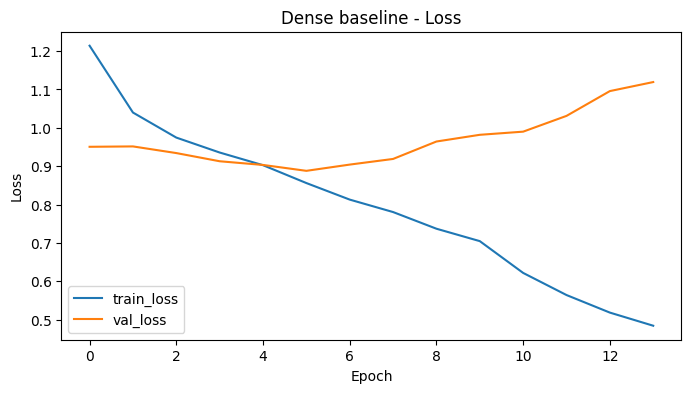

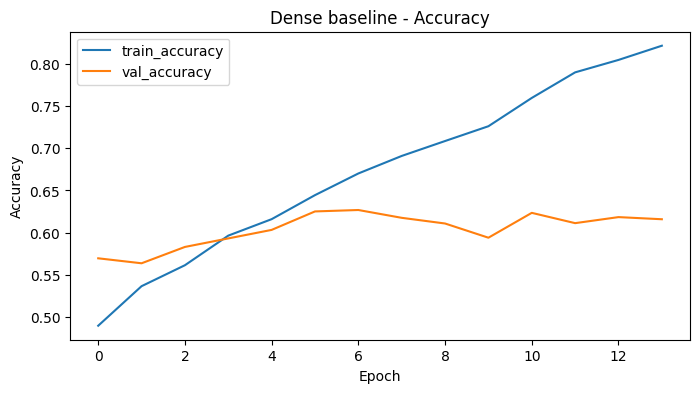

75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step  
Accuracy: 0.6323529411764706
Macro F1: 0.5638702940680633
Weighted F1: 0.6318674048977803

              precision    recall  f1-score   support

       SEG_A       0.77      0.77      0.77      1282
       SEG_B       0.50      0.52      0.51       669
       SEG_C       0.42      0.40      0.41       429

    accuracy                           0.63      2380
   macro avg       0.57      0.56      0.56      2380
weighted avg       0.63      0.63      0.63      2380



,SEG_A,SEG_B,SEG_C
SEG_A,984,198,100
SEG_B,186,350,133
SEG_C,111,147,171


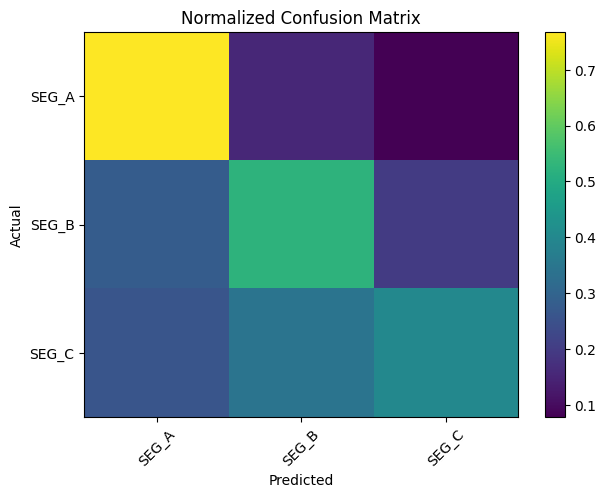

In [29]:
# %%
plot_history(history_dense, "Dense baseline")

dense_results = evaluate_keras_model(
    dense_model,
    X_test,
    y_test,
    target_names
)

## CNN model

In [28]:
# CNN model
tf.keras.backend.clear_session()

tf.keras.backend.clear_session()

cnn_model = models.Sequential([
    layers.Input(shape=(n_weeks, n_features)),

    layers.BatchNormalization(),

    layers.Conv1D(64, 3, padding="same", activation="relu", kernel_regularizer=regularizers.l2(1e-4)),
    layers.BatchNormalization(),
    layers.Dropout(0.3),

    layers.Conv1D(64, 5, padding="same", activation="relu", kernel_regularizer=regularizers.l2(1e-4)),
    layers.BatchNormalization(),
    layers.Dropout(0.3),

    layers.Conv1D(128, 3, padding="same", activation="relu", kernel_regularizer=regularizers.l2(1e-4)),
    layers.BatchNormalization(),
    layers.Dropout(0.35),

    layers.GlobalAveragePooling1D(),

    layers.Dense(64, activation="relu"),
    layers.Dropout(0.4),

    layers.Dense(n_classes, activation="softmax")
])

cnn_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=5e-4),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

cnn_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ batch_normalization             │ (None, 86, 65)         │           260 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d (Conv1D)                 │ (None, 86, 64)         │        12,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 86, 64)         │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 86, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 86, 64)         │        20,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 86, 64)         │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 86, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_2 (Conv1D)               │ (None, 86, 128)        │        24,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 86, 128)        │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 86, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 67,527 (263.78 KB)

 Trainable params: 66,885 (261.27 KB)

 Non-trainable params: 642 (2.51 KB)

In [29]:
# Define callbacks for CNN model
early_stop_cnn = callbacks.EarlyStopping(
    monitor="val_loss",
    patience=10,
    restore_best_weights=True
)

reduce_lr_cnn = callbacks.ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=4,
    min_lr=1e-5
)

In [30]:
# %%
history_cnn = cnn_model.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=80,
    batch_size=64,
    class_weight=class_weight,
    callbacks=[early_stop_cnn, reduce_lr_cnn],
    verbose=1
)

Epoch 1/80
112/112 ━━━━━━━━━━━━━━━━━━━━ 5s 29ms/step - accuracy: 0.5475 - loss: 1.0207 - val_accuracy: 0.5586 - val_loss: 0.9915 - learning_rate: 5.0000e-04
Epoch 2/80
112/112 ━━━━━━━━━━━━━━━━━━━━ 3s 28ms/step - accuracy: 0.5885 - loss: 0.9590 - val_accuracy: 0.5792 - val_loss: 0.9443 - learning_rate: 5.0000e-04
Epoch 3/80
112/112 ━━━━━━━━━━━━━━━━━━━━ 3s 27ms/step - accuracy: 0.6097 - loss: 0.9402 - val_accuracy: 0.6124 - val_loss: 0.8936 - learning_rate: 5.0000e-04
Epoch 4/80
112/112 ━━━━━━━━━━━━━━━━━━━━ 3s 27ms/step - accuracy: 0.6085 - loss: 0.9285 - val_accuracy: 0.6183 - val_loss: 0.8933 - learning_rate: 5.0000e-04
Epoch 5/80
112/112 ━━━━━━━━━━━━━━━━━━━━ 3s 26ms/step - accuracy: 0.6178 - loss: 0.9069 - val_accuracy: 0.6217 - val_loss: 0.8765 - learning_rate: 5.0000e-04
Epoch 6/80
112/112 ━━━━━━━━━━━━━━━━━━━━ 3s 27ms/step - accuracy: 0.6246 - loss: 0.9081 - val_accuracy: 0.5994 - val_loss: 0.9148 - learning_rate: 5.0000e-04
Epoch 7/80
112/112 ━━━━━━━━━━━━━━━━━━━━ 3s 27ms/step - acc

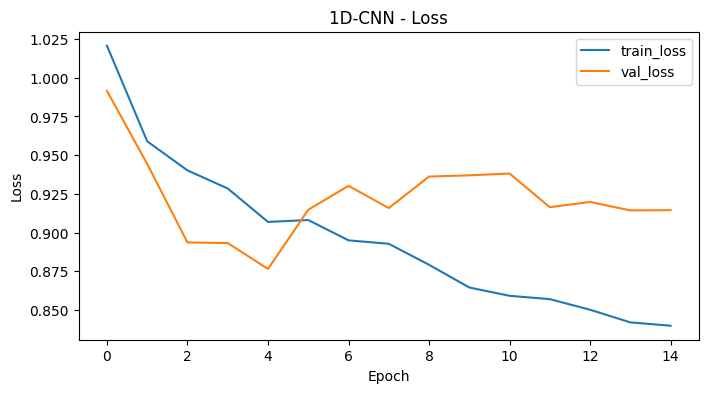

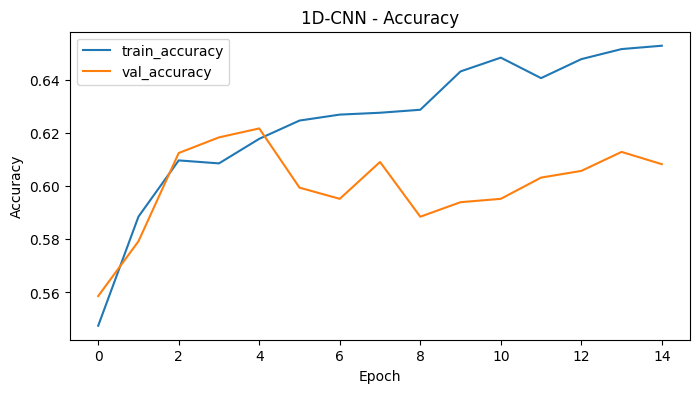

75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
Accuracy: 0.6210084033613446
Macro F1: 0.56469944397133
Weighted F1: 0.6285512554163031

              precision    recall  f1-score   support

       SEG_A       0.79      0.71      0.75      1281
       SEG_B       0.51      0.59      0.55       670
       SEG_C       0.38      0.42      0.40       429

    accuracy                           0.62      2380
   macro avg       0.56      0.57      0.56      2380
weighted avg       0.64      0.62      0.63      2380



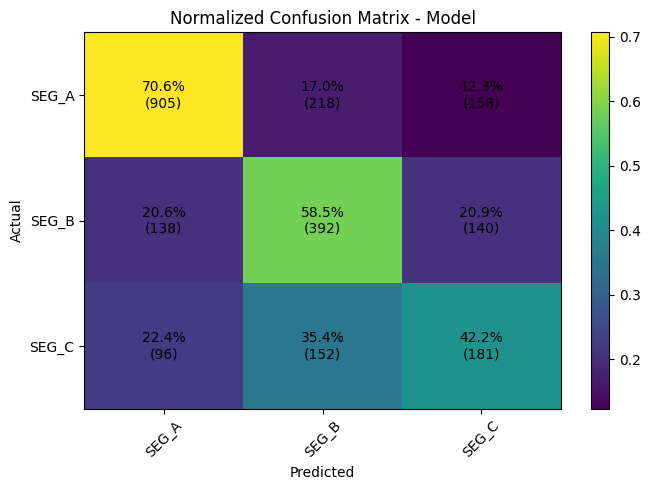

In [31]:
# %%
plot_history(history_cnn, "1D-CNN")

cnn_results = evaluate_keras_model(
    cnn_model,
    X_test,
    y_test,
    target_names
)

In [23]:
# 1. Predict probabilities on the test set
proba = cnn_model.predict(X_test)

# 2. True labels
y_true = y_test.numpy()

# 3. SEG_C index
seg_c_idx = 2  # SEG_A=0, SEG_B=1, SEG_C=2

threshold_results = []

y_pred_default = np.argmax(proba, axis=1)

print("Default prediction")
print("Accuracy:", accuracy_score(y_true, y_pred_default))
print("Macro F1:", f1_score(y_true, y_pred_default, average="macro"))
print("Weighted F1:", f1_score(y_true, y_pred_default, average="weighted"))
print(classification_report(y_true, y_pred_default, target_names=target_names))

for t in [0.30, 0.35, 0.40, 0.45, 0.50]:
    # Base prediction: class with highest probability
    y_pred_t = np.argmax(proba, axis=1)
    
    # Override prediction to SEG_C if its probability passes threshold
    y_pred_t[proba[:, seg_c_idx] >= t] = seg_c_idx
    
    print(f"\nThreshold SEG_C: {t}")
    print(classification_report(y_true, y_pred_t, target_names=target_names))

    report = classification_report(
        y_true,
        y_pred_t,
        target_names=target_names,
        output_dict=True
    )
    
    threshold_results.append({
        "threshold": t,
        "accuracy": accuracy_score(y_true, y_pred_t),
        "macro_f1": f1_score(y_true, y_pred_t, average="macro"),
        "weighted_f1": f1_score(y_true, y_pred_t, average="weighted"),
        "SEG_C_precision": report["SEG_C"]["precision"],
        "SEG_C_recall": report["SEG_C"]["recall"],
        "SEG_C_f1": report["SEG_C"]["f1-score"]
    })

threshold_df = pd.DataFrame(threshold_results)
threshold_df

75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
Default prediction
Accuracy: 0.603781512605042
Macro F1: 0.5588422841095569
Weighted F1: 0.6162794447322821
              precision    recall  f1-score   support

       SEG_A       0.80      0.68      0.74      1281
       SEG_B       0.53      0.48      0.50       670
       SEG_C       0.36      0.57      0.44       429

    accuracy                           0.60      2380
   macro avg       0.56      0.58      0.56      2380
weighted avg       0.64      0.60      0.62      2380


Threshold SEG_C: 0.3
              precision    recall  f1-score   support

       SEG_A       0.82      0.57      0.68      1281
       SEG_B       0.51      0.26      0.34       670
       SEG_C       0.30      0.79      0.43       429

    accuracy                           0.52      2380
   macro avg       0.54      0.54      0.48      2380
weighted avg       0.64      0.52      0.54      2380


Threshold SEG_C: 0.35
              precision    recall  f1-score   

,threshold,accuracy,macro_f1,weighted_f1,SEG_C_precision,SEG_C_recall,SEG_C_f1
0,0.30,0.523950,0.483019,0.538089,0.295039,0.790210,0.429658
1,0.35,0.557983,0.515526,0.571361,0.321244,0.722611,0.444763
2,0.40,0.586134,0.541013,0.598310,0.345966,0.659674,0.453889
3,0.45,0.601681,0.557545,0.613755,0.360724,0.603730,0.451613
4,0.50,0.603782,0.558842,0.616279,0.357879,0.566434,0.438628


## GRU model

In [32]:
# GRU model
tf.keras.backend.clear_session()

gru_model = models.Sequential([
    layers.Input(shape=(n_weeks, n_features)),
    
    layers.BatchNormalization(),
    
    layers.GRU(
        64,
        return_sequences=True,
        dropout=0.2,
        recurrent_dropout=0.0
    ),
    
    layers.GRU(
        64,
        return_sequences=False,
        dropout=0.2,
        recurrent_dropout=0.0
    ),
    
    layers.Dense(64, activation="relu"),
    layers.Dropout(0.3),
    
    layers.Dense(n_classes, activation="softmax")
])

gru_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

gru_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ batch_normalization             │ (None, 86, 65)         │           260 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru (GRU)                       │ (None, 86, 64)         │        25,152 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_1 (GRU)                     │ (None, 64)             │        24,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 54,727 (213.78 KB)

 Trainable params: 54,597 (213.27 KB)

 Non-trainable params: 130 (520.00 B)

In [33]:
# %%
early_stop_gru = callbacks.EarlyStopping(
    monitor="val_loss",
    patience=10,
    restore_best_weights=True
)

reduce_lr_gru = callbacks.ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=4,
    min_lr=1e-5
)

history_gru = gru_model.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=80,
    batch_size=64,
    class_weight=class_weight,
    callbacks=[early_stop_gru, reduce_lr_gru],
    verbose=1
)

Epoch 1/80
112/112 ━━━━━━━━━━━━━━━━━━━━ 10s 70ms/step - accuracy: 0.5206 - loss: 1.0305 - val_accuracy: 0.5237 - val_loss: 1.0048 - learning_rate: 0.0010
Epoch 2/80
112/112 ━━━━━━━━━━━━━━━━━━━━ 7s 66ms/step - accuracy: 0.5613 - loss: 0.9878 - val_accuracy: 0.5485 - val_loss: 0.9698 - learning_rate: 0.0010
Epoch 3/80
112/112 ━━━━━━━━━━━━━━━━━━━━ 7s 67ms/step - accuracy: 0.5667 - loss: 0.9800 - val_accuracy: 0.5502 - val_loss: 0.9679 - learning_rate: 0.0010
Epoch 4/80
112/112 ━━━━━━━━━━━━━━━━━━━━ 8s 70ms/step - accuracy: 0.5738 - loss: 0.9689 - val_accuracy: 0.5633 - val_loss: 0.9688 - learning_rate: 0.0010
Epoch 5/80
112/112 ━━━━━━━━━━━━━━━━━━━━ 7s 67ms/step - accuracy: 0.5805 - loss: 0.9616 - val_accuracy: 0.5603 - val_loss: 0.9617 - learning_rate: 0.0010
Epoch 6/80
112/112 ━━━━━━━━━━━━━━━━━━━━ 8s 68ms/step - accuracy: 0.5873 - loss: 0.9543 - val_accuracy: 0.5818 - val_loss: 0.9314 - learning_rate: 0.0010
Epoch 7/80
112/112 ━━━━━━━━━━━━━━━━━━━━ 8s 71ms/step - accuracy: 0.5937 - loss: 0

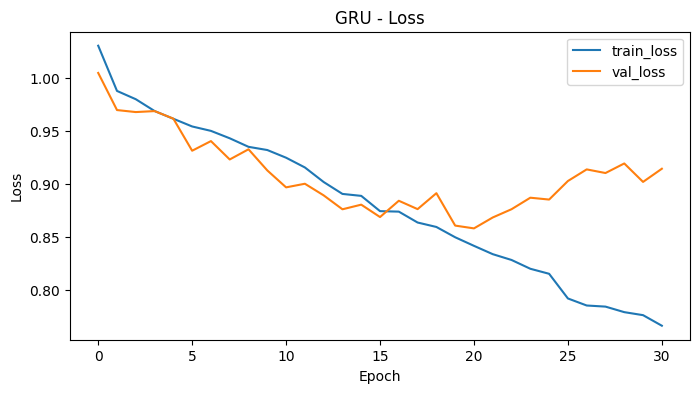

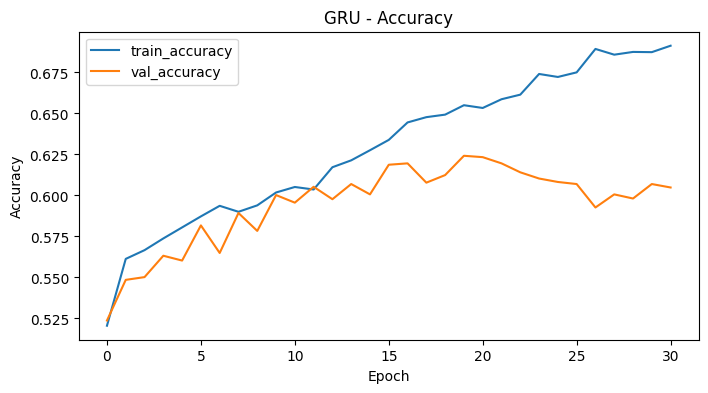

75/75 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step
Accuracy: 0.6105042016806723
Macro F1: 0.5494308796622267
Weighted F1: 0.6173593354441685

              precision    recall  f1-score   support

       SEG_A       0.78      0.74      0.76      1281
       SEG_B       0.53      0.44      0.48       670
       SEG_C       0.35      0.49      0.41       429

    accuracy                           0.61      2380
   macro avg       0.55      0.56      0.55      2380
weighted avg       0.63      0.61      0.62      2380



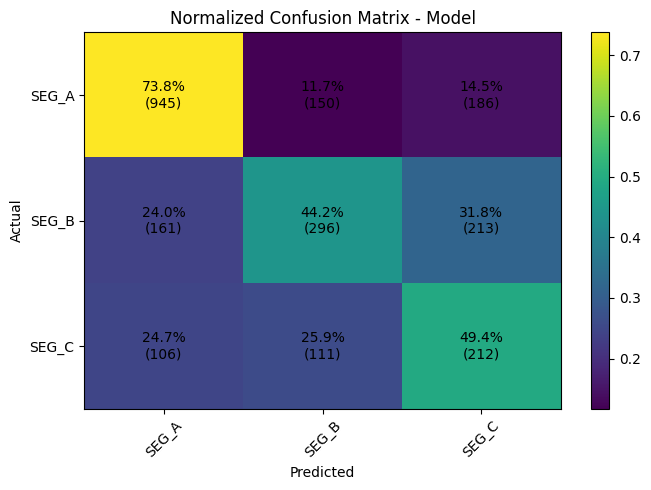

In [34]:
# Plot GRU training history
plot_history(history_gru, "GRU")

gru_results = evaluate_keras_model(
    gru_model,
    X_test,
    y_test,
    target_names
)

In [37]:
# %%
model_comparison = pd.DataFrame([
    {
        "model": "Dense baseline",
        "accuracy": dense_results["accuracy"],
        "macro_f1": dense_results["macro_f1"],
        "weighted_f1": dense_results["weighted_f1"]
    },
    {
        "model": "1D-CNN",
        "accuracy": cnn_results["accuracy"],
        "macro_f1": cnn_results["macro_f1"],
        "weighted_f1": cnn_results["weighted_f1"]
    },
    {
        "model": "GRU",
        "accuracy": gru_results["accuracy"],
        "macro_f1": gru_results["macro_f1"],
        "weighted_f1": gru_results["weighted_f1"]
    }
])

model_comparison

,model,accuracy,macro_f1,weighted_f1
0,Dense baseline,0.632353,0.563870,0.631867
1,1D-CNN,0.628571,0.571127,0.635842
2,GRU,0.625630,0.559430,0.628134


## Mixed model architecture

In [38]:
tf.keras.backend.clear_session()

hybrid_model = models.Sequential([
    layers.Input(shape=(n_weeks, n_features)),

    layers.BatchNormalization(),

    layers.Conv1D(
        filters=64,
        kernel_size=3,
        padding="same",
        activation="relu"
    ),
    layers.BatchNormalization(),
    layers.Dropout(0.2),

    layers.Conv1D(
        filters=64,
        kernel_size=5,
        padding="same",
        activation="relu"
    ),
    layers.BatchNormalization(),
    layers.MaxPooling1D(pool_size=2),
    layers.Dropout(0.25),

    layers.GRU(
        64,
        return_sequences=False,
        dropout=0.25,
        recurrent_dropout=0.0
    ),

    layers.Dense(64, activation="relu"),
    layers.Dropout(0.3),

    layers.Dense(n_classes, activation="softmax")
])

hybrid_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=7e-4),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

hybrid_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ batch_normalization             │ (None, 86, 65)         │           260 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d (Conv1D)                 │ (None, 86, 64)         │        12,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 86, 64)         │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 86, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 86, 64)         │        20,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 86, 64)         │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 43, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 43, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru (GRU)                       │ (None, 64)             │        24,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 63,175 (246.78 KB)

 Trainable params: 62,789 (245.27 KB)

 Non-trainable params: 386 (1.51 KB)

In [39]:
early_stop_hybrid = callbacks.EarlyStopping(
    monitor="val_loss",
    patience=10,
    restore_best_weights=True
)

reduce_lr_hybrid = callbacks.ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=4,
    min_lr=1e-5
)

history_hybrid = hybrid_model.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=80,
    batch_size=64,
    class_weight=class_weight,
    callbacks=[early_stop_hybrid, reduce_lr_hybrid],
    verbose=1
)

Epoch 1/80
112/112 ━━━━━━━━━━━━━━━━━━━━ 5s 21ms/step - accuracy: 0.4554 - loss: 1.0717 - val_accuracy: 0.5643 - val_loss: 0.9835 - learning_rate: 7.0000e-04
Epoch 2/80
112/112 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - accuracy: 0.5494 - loss: 0.9887 - val_accuracy: 0.5714 - val_loss: 0.9407 - learning_rate: 7.0000e-04
Epoch 3/80
112/112 ━━━━━━━━━━━━━━━━━━━━ 2s 21ms/step - accuracy: 0.5657 - loss: 0.9697 - val_accuracy: 0.5773 - val_loss: 0.9292 - learning_rate: 7.0000e-04
Epoch 4/80
112/112 ━━━━━━━━━━━━━━━━━━━━ 3s 22ms/step - accuracy: 0.5698 - loss: 0.9630 - val_accuracy: 0.5761 - val_loss: 0.9467 - learning_rate: 7.0000e-04
Epoch 5/80
112/112 ━━━━━━━━━━━━━━━━━━━━ 2s 21ms/step - accuracy: 0.5836 - loss: 0.9497 - val_accuracy: 0.5832 - val_loss: 0.9275 - learning_rate: 7.0000e-04
Epoch 6/80
112/112 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - accuracy: 0.5925 - loss: 0.9365 - val_accuracy: 0.5798 - val_loss: 0.9364 - learning_rate: 7.0000e-04
Epoch 7/80
112/112 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - acc

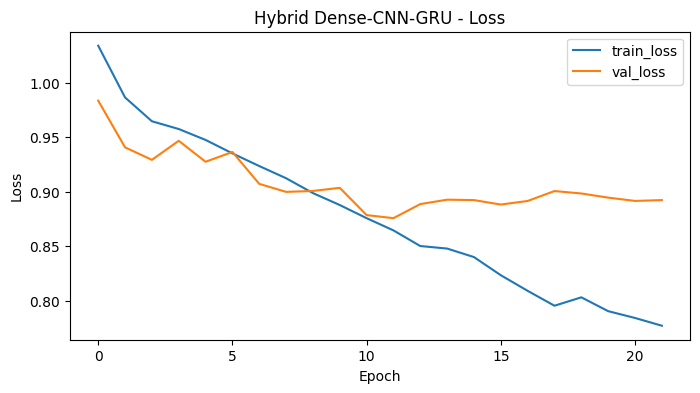

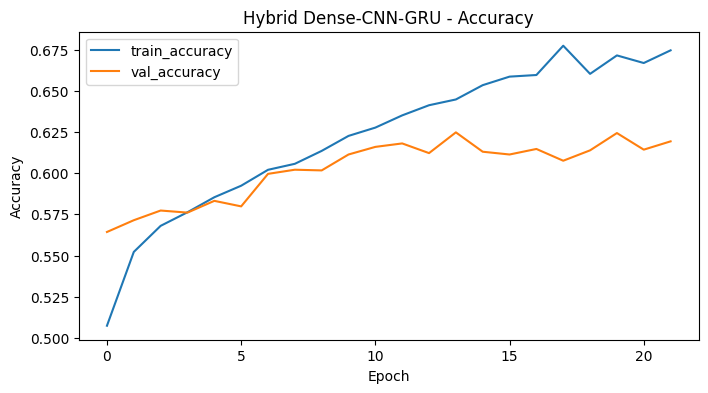

75/75 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step
Accuracy: 0.619327731092437
Macro F1: 0.5565139378689925
Weighted F1: 0.6248160993399645

              precision    recall  f1-score   support

       SEG_A       0.78      0.75      0.76      1282
       SEG_B       0.54      0.47      0.51       669
       SEG_C       0.35      0.47      0.40       429

    accuracy                           0.62      2380
   macro avg       0.56      0.56      0.56      2380
weighted avg       0.63      0.62      0.62      2380



,SEG_A,SEG_B,SEG_C
SEG_A,958,153,171
SEG_B,160,316,193
SEG_C,116,113,200


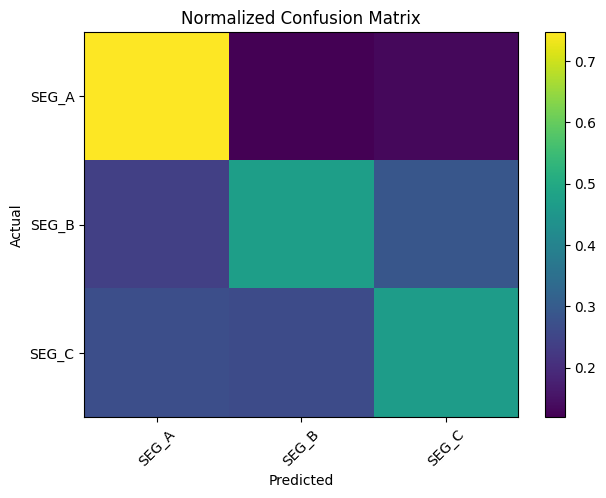

In [40]:
plot_history(history_hybrid, "Hybrid Dense-CNN-GRU")

hybrid_results = evaluate_keras_model(
    hybrid_model,
    X_test,
    y_test,
    target_names
)

## CNN folds test

In [63]:
fold_results = []

all_folds = sorted(np.unique(fold_labeled.numpy()))
all_folds = [f for f in all_folds if f != -1]

for test_fold in all_folds:
    for val_fold in all_folds:
        if val_fold == test_fold:
            continue
    
        print(f"\n==============================")
        print(f"Test fold: {test_fold} | Val fold: {val_fold}")
        print(f"==============================")
        
        train_mask = (fold_labeled != test_fold) & (fold_labeled != val_fold)
        val_mask = fold_labeled == val_fold
        test_mask = fold_labeled == test_fold
        
        X_train = tf.boolean_mask(X_labeled, train_mask)
        y_train = tf.boolean_mask(y_labeled, train_mask)
        
        X_val = tf.boolean_mask(X_labeled, val_mask)
        y_val = tf.boolean_mask(y_labeled, val_mask)
        
        X_test = tf.boolean_mask(X_labeled, test_mask)
        y_test = tf.boolean_mask(y_labeled, test_mask)
        
        print("Train:", X_train.shape, y_train.shape)
        print("Val:", X_val.shape, y_val.shape)
        print("Test:", X_test.shape, y_test.shape)
        
        # Class weights for this fold
        y_train_np = y_train.numpy()
        classes = np.unique(y_train_np)
        
        weights = compute_class_weight(
            class_weight="balanced",
            classes=classes,
            y=y_train_np
        )
        
        class_weight_fold = dict(zip(classes, weights))
        
        # Build fresh model for each fold
        tf.keras.backend.clear_session()
        
        model = models.Sequential([
        layers.Input(shape=(n_weeks, n_features)),

        layers.BatchNormalization(),

        layers.Conv1D(64, 3, padding="same", activation="relu", kernel_regularizer=regularizers.l2(1e-4)),
        layers.BatchNormalization(),
        layers.Dropout(0.3),

        layers.Conv1D(64, 5, padding="same", activation="relu", kernel_regularizer=regularizers.l2(1e-4)),
        layers.BatchNormalization(),
        layers.Dropout(0.3),

        layers.Conv1D(128, 3, padding="same", activation="relu", kernel_regularizer=regularizers.l2(1e-4)),
        layers.BatchNormalization(),
        layers.Dropout(0.35),

        layers.GlobalAveragePooling1D(),

        layers.Dense(64, activation="relu"),
        layers.Dropout(0.4),

        layers.Dense(n_classes, activation="softmax")
    ])

        model.compile(
            optimizer=tf.keras.optimizers.Adam(learning_rate=5e-4),
            loss="sparse_categorical_crossentropy",
            metrics=["accuracy"]
        )
        
        early_stop = callbacks.EarlyStopping(
            monitor="val_loss",
            patience=8,
            restore_best_weights=True
        )
        
        reduce_lr = callbacks.ReduceLROnPlateau(
            monitor="val_loss",
            factor=0.5,
            patience=4,
            min_lr=1e-5
        )
        
        history = model.fit(
            X_train,
            y_train,
            validation_data=(X_val, y_val),
            epochs=60,
            batch_size=64,
            class_weight=class_weight_fold,
            callbacks=[early_stop, reduce_lr],
            verbose=0
        )
        
        # Evaluate
        proba = model.predict(X_test, verbose=0)
        y_pred = np.argmax(proba, axis=1)
        y_true = y_test.numpy()
        
        acc = accuracy_score(y_true, y_pred)
        macro = f1_score(y_true, y_pred, average="macro")
        weighted = f1_score(y_true, y_pred, average="weighted")
        
        report = classification_report(
            y_true,
            y_pred,
            target_names=target_names,
            output_dict=True
        )
        
        fold_results.append({
            "test_fold": test_fold,
            "val_fold": val_fold,
            "accuracy": acc,
            "macro_f1": macro,
            "weighted_f1": weighted,
            "SEG_A_recall": report["SEG_A"]["recall"],
            "SEG_B_recall": report["SEG_B"]["recall"],
            "SEG_C_recall": report["SEG_C"]["recall"],
            "epochs_trained": len(history.history["loss"])
        })
        
        print(f"Accuracy: {acc:.4f}")
        print(f"Macro F1: {macro:.4f}")
        print(f"Weighted F1: {weighted:.4f}")
        print(f"SEG_B recall: {report['SEG_B']['recall']:.4f}")
        print(f"SEG_C recall: {report['SEG_C']['recall']:.4f}")


Test fold: 0 | Val fold: 1
Train: (7139, 86, 65) (7139,)
Val: (2380, 86, 65) (2380,)
Test: (2380, 86, 65) (2380,)
Accuracy: 0.6458
Macro F1: 0.5864
Weighted F1: 0.6501
SEG_B recall: 0.5262
SEG_C recall: 0.4825

Test fold: 0 | Val fold: 2
Train: (7139, 86, 65) (7139,)
Val: (2380, 86, 65) (2380,)
Test: (2380, 86, 65) (2380,)
Accuracy: 0.6273
Macro F1: 0.5549
Weighted F1: 0.6245
SEG_B recall: 0.3513
SEG_C recall: 0.5594

Test fold: 0 | Val fold: 3
Train: (7139, 86, 65) (7139,)
Val: (2380, 86, 65) (2380,)
Test: (2380, 86, 65) (2380,)
Accuracy: 0.6395
Macro F1: 0.5770
Weighted F1: 0.6412
SEG_B recall: 0.4619
SEG_C recall: 0.5082

Test fold: 0 | Val fold: 4
Train: (7140, 86, 65) (7140,)
Val: (2379, 86, 65) (2379,)
Test: (2380, 86, 65) (2380,)
Accuracy: 0.6206
Macro F1: 0.5616
Weighted F1: 0.6261
SEG_B recall: 0.4529
SEG_C recall: 0.5082

Test fold: 1 | Val fold: 0
Train: (7139, 86, 65) (7139,)
Val: (2380, 86, 65) (2380,)
Test: (2380, 86, 65) (2380,)
Accuracy: 0.6424
Macro F1: 0.5709
Weighte

In [64]:
fold_results_df = pd.DataFrame(fold_results)
fold_results_df

,test_fold,val_fold,accuracy,macro_f1,weighted_f1,SEG_A_recall,SEG_B_recall,SEG_C_recall,epochs_trained
0,0,1,0.645798,0.586448,0.650101,0.762871,0.526158,0.482517,16
1,0,2,0.627311,0.554915,0.624519,0.794072,0.351271,0.559441,15
2,0,3,0.639496,0.576964,0.641226,0.776131,0.461883,0.508159,16
3,0,4,0.620588,0.561621,0.626067,0.745710,0.452915,0.508159,22
4,1,0,0.642437,0.570927,0.639242,0.800156,0.470149,0.440559,12
5,1,2,0.644958,0.575105,0.645660,0.780640,0.537313,0.407925,29
6,1,3,0.607143,0.556172,0.619027,0.691647,0.528358,0.477855,16
7,1,4,0.614706,0.547334,0.617073,0.763466,0.411940,0.487179,11
8,2,0,0.643277,0.563876,0.633555,0.832943,0.356716,0.524476,13
9,2,1,0.635294,0.543420,0.621460,0.845433,0.404478,0.368298,11


In [65]:
fold_results_df.sort_values("macro_f1", ascending=False).head(10)

,test_fold,val_fold,accuracy,macro_f1,weighted_f1,SEG_A_recall,SEG_B_recall,SEG_C_recall,epochs_trained
0,0,1,0.645798,0.586448,0.650101,0.762871,0.526158,0.482517,16
15,3,4,0.648739,0.585103,0.649697,0.791569,0.444776,0.540793,12
14,3,2,0.634034,0.578698,0.639419,0.742389,0.511940,0.501166,16
2,0,3,0.639496,0.576964,0.641226,0.776131,0.461883,0.508159,16
5,1,2,0.644958,0.575105,0.645660,0.780640,0.537313,0.407925,29
4,1,0,0.642437,0.570927,0.639242,0.800156,0.470149,0.440559,12
12,3,0,0.623109,0.570037,0.631961,0.728337,0.483582,0.526807,17
11,2,4,0.630252,0.569659,0.632879,0.761905,0.447761,0.522145,13
10,2,3,0.633613,0.566441,0.633781,0.785324,0.435821,0.489510,13
13,3,1,0.624370,0.565829,0.629535,0.745511,0.470149,0.503497,14


In [66]:
fold_results_df.sort_values("SEG_C_recall", ascending=False).head(10)

,test_fold,val_fold,accuracy,macro_f1,weighted_f1,SEG_A_recall,SEG_B_recall,SEG_C_recall,epochs_trained
1,0,2,0.627311,0.554915,0.624519,0.794072,0.351271,0.559441,15
15,3,4,0.648739,0.585103,0.649697,0.791569,0.444776,0.540793,12
19,4,3,0.596469,0.552352,0.611162,0.667447,0.502985,0.530374,12
12,3,0,0.623109,0.570037,0.631961,0.728337,0.483582,0.526807,17
8,2,0,0.643277,0.563876,0.633555,0.832943,0.356716,0.524476,13
11,2,4,0.630252,0.569659,0.632879,0.761905,0.447761,0.522145,13
2,0,3,0.639496,0.576964,0.641226,0.776131,0.461883,0.508159,16
3,0,4,0.620588,0.561621,0.626067,0.745710,0.452915,0.508159,22
13,3,1,0.624370,0.565829,0.629535,0.745511,0.470149,0.503497,14
14,3,2,0.634034,0.578698,0.639419,0.742389,0.511940,0.501166,16


## CNN learning rate, batch size and dropout tests

In [35]:
def build_cnn_model(
    n_weeks,
    n_features,
    n_classes,
    learning_rate=5e-4,
    dropout_config=(0.3, 0.3, 0.35, 0.4),
    l2_reg=1e-4
):
    d1, d2, d3, d_dense = dropout_config
    
    tf.keras.backend.clear_session()
    tf.keras.utils.set_random_seed(SEED)
    
    model = models.Sequential([
        layers.Input(shape=(n_weeks, n_features)),

        layers.BatchNormalization(),

        layers.Conv1D(
            64,
            3,
            padding="same",
            activation="relu",
            kernel_regularizer=regularizers.l2(l2_reg)
        ),
        layers.BatchNormalization(),
        layers.Dropout(d1),

        layers.Conv1D(
            64,
            5,
            padding="same",
            activation="relu",
            kernel_regularizer=regularizers.l2(l2_reg)
        ),
        layers.BatchNormalization(),
        layers.Dropout(d2),

        layers.Conv1D(
            128,
            3,
            padding="same",
            activation="relu",
            kernel_regularizer=regularizers.l2(l2_reg)
        ),
        layers.BatchNormalization(),
        layers.Dropout(d3),

        layers.GlobalAveragePooling1D(),

        layers.Dense(
            64,
            activation="relu",
            kernel_regularizer=regularizers.l2(l2_reg)
        ),
        layers.Dropout(d_dense),

        layers.Dense(n_classes, activation="softmax")
    ])
    
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=learning_rate),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )
    
    return model

In [36]:
def evaluate_on_split(model, X_eval, y_eval, target_names):
    proba = model.predict(X_eval, verbose=0)
    y_pred = np.argmax(proba, axis=1)
    y_true = y_eval.numpy()
    
    report = classification_report(
        y_true,
        y_pred,
        target_names=target_names,
        output_dict=True
    )
    
    return {
        "accuracy": accuracy_score(y_true, y_pred),
        "macro_f1": f1_score(y_true, y_pred, average="macro"),
        "weighted_f1": f1_score(y_true, y_pred, average="weighted"),
        "SEG_A_recall": report["SEG_A"]["recall"],
        "SEG_B_recall": report["SEG_B"]["recall"],
        "SEG_C_recall": report["SEG_C"]["recall"],
        "SEG_A_f1": report["SEG_A"]["f1-score"],
        "SEG_B_f1": report["SEG_B"]["f1-score"],
        "SEG_C_f1": report["SEG_C"]["f1-score"],
    }

In [37]:
learning_rates = [1e-3, 7e-4, 5e-4, 3e-4]

batch_sizes = [32, 64, 128]

dropout_configs = {
    "low_dropout": (0.15, 0.15, 0.20, 0.25),
    "medium_dropout": (0.20, 0.20, 0.25, 0.30),
    "high_dropout": (0.30, 0.30, 0.35, 0.40),
}

In [39]:
cnn_tuning_results = []

for lr in learning_rates:
    for batch_size in batch_sizes:
        for dropout_name, dropout_config in dropout_configs.items():
            
            print("\n===================================")
            print(f"LR={lr} | Batch={batch_size} | Dropout={dropout_name}")
            print("===================================")
            
            model = build_cnn_model(
                n_weeks=n_weeks,
                n_features=n_features,
                n_classes=n_classes,
                learning_rate=lr,
                dropout_config=dropout_config,
                l2_reg=1e-4
            )
            
            early_stop = callbacks.EarlyStopping(
                monitor="val_loss",
                patience=8,
                restore_best_weights=True
            )
            
            reduce_lr = callbacks.ReduceLROnPlateau(
                monitor="val_loss",
                factor=0.5,
                patience=4,
                min_lr=1e-5
            )
            
            history = model.fit(
                X_train,
                y_train,
                validation_data=(X_val, y_val),
                epochs=60,
                batch_size=batch_size,
                class_weight=class_weight,
                callbacks=[early_stop, reduce_lr],
                verbose=0
            )
            
            val_metrics = evaluate_on_split(
                model,
                X_val,
                y_val,
                target_names
            )
            
            result = {
                "learning_rate": lr,
                "batch_size": batch_size,
                "dropout_name": dropout_name,
                "dropout_config": str(dropout_config),
                "epochs_trained": len(history.history["loss"]),
                "best_val_loss": min(history.history["val_loss"]),
                "best_val_accuracy": max(history.history["val_accuracy"]),
                **val_metrics
            }
            
            cnn_tuning_results.append(result)
            
            print(
                f"Val Macro F1: {val_metrics['macro_f1']:.4f} | "
                f"Val Weighted F1: {val_metrics['weighted_f1']:.4f} | "
                f"SEG_C Recall: {val_metrics['SEG_C_recall']:.4f}"
            )


LR=0.001 | Batch=32 | Dropout=low_dropout
Val Macro F1: 0.5461 | Val Weighted F1: 0.6246 | SEG_C Recall: 0.3294

LR=0.001 | Batch=32 | Dropout=medium_dropout
Val Macro F1: 0.5431 | Val Weighted F1: 0.6205 | SEG_C Recall: 0.3668

LR=0.001 | Batch=32 | Dropout=high_dropout
Val Macro F1: 0.5414 | Val Weighted F1: 0.6187 | SEG_C Recall: 0.3715

LR=0.001 | Batch=64 | Dropout=low_dropout
Val Macro F1: 0.5648 | Val Weighted F1: 0.6297 | SEG_C Recall: 0.5164

LR=0.001 | Batch=64 | Dropout=medium_dropout
Val Macro F1: 0.5631 | Val Weighted F1: 0.6316 | SEG_C Recall: 0.5047

LR=0.001 | Batch=64 | Dropout=high_dropout
Val Macro F1: 0.5676 | Val Weighted F1: 0.6368 | SEG_C Recall: 0.4743

LR=0.001 | Batch=128 | Dropout=low_dropout
Val Macro F1: 0.5753 | Val Weighted F1: 0.6446 | SEG_C Recall: 0.5234

LR=0.001 | Batch=128 | Dropout=medium_dropout
Val Macro F1: 0.5702 | Val Weighted F1: 0.6393 | SEG_C Recall: 0.4860

LR=0.001 | Batch=128 | Dropout=high_dropout
Val Macro F1: 0.5749 | Val Weighted F1

In [41]:
cnn_tuning_df = pd.DataFrame(cnn_tuning_results)

cnn_tuning_df.sort_values(
    ["macro_f1", "SEG_C_recall", "accuracy", "SEG_B_recall", "SEG_A_recall"],
    ascending=False
).head(10)

,learning_rate,batch_size,dropout_name,dropout_config,epochs_trained,best_val_loss,best_val_accuracy,accuracy,macro_f1,weighted_f1,SEG_A_recall,SEG_B_recall,SEG_C_recall,SEG_A_f1,SEG_B_f1,SEG_C_f1
35,0.0003,128,high_dropout,"(0.3, 0.3, 0.35, 0.4)",24,0.838356,0.658260,0.658260,0.590563,0.655888,0.813427,0.455224,0.511682,0.790592,0.527682,0.453416
34,0.0003,128,medium_dropout,"(0.2, 0.2, 0.25, 0.3)",24,0.838361,0.656999,0.655317,0.586739,0.654043,0.811085,0.449254,0.511682,0.792525,0.523023,0.444670
33,0.0003,128,low_dropout,"(0.15, 0.15, 0.2, 0.25)",28,0.854065,0.651114,0.651114,0.586524,0.651542,0.795472,0.455224,0.525701,0.785962,0.522708,0.450902
16,0.0007,128,medium_dropout,"(0.2, 0.2, 0.25, 0.3)",15,0.849731,0.651955,0.651955,0.585940,0.652104,0.799375,0.458209,0.514019,0.787692,0.525235,0.444894
17,0.0007,128,high_dropout,"(0.3, 0.3, 0.35, 0.4)",15,0.840159,0.651114,0.648592,0.579446,0.647263,0.800937,0.470149,0.471963,0.784404,0.523691,0.430245
25,0.0005,128,medium_dropout,"(0.2, 0.2, 0.25, 0.3)",15,0.849861,0.649433,0.648172,0.579383,0.647974,0.800937,0.456716,0.490654,0.787414,0.520408,0.430328
26,0.0005,128,high_dropout,"(0.3, 0.3, 0.35, 0.4)",15,0.843703,0.656999,0.646910,0.577937,0.644830,0.804840,0.432836,0.509346,0.784627,0.506993,0.442191
24,0.0005,128,low_dropout,"(0.15, 0.15, 0.2, 0.25)",15,0.862032,0.646070,0.640185,0.577009,0.642287,0.779859,0.444776,0.528037,0.777130,0.513351,0.440546
30,0.0003,64,low_dropout,"(0.15, 0.15, 0.2, 0.25)",22,0.865200,0.637663,0.637663,0.576980,0.641596,0.770492,0.440299,0.549065,0.775334,0.513043,0.442561
14,0.0007,64,high_dropout,"(0.3, 0.3, 0.35, 0.4)",13,0.850044,0.646070,0.643968,0.575765,0.643732,0.798595,0.425373,0.523364,0.786318,0.501761,0.439216


## Final CNN model

In [42]:
learning_rates = [2e-4, 3e-4, 4e-4]
batch_sizes = [128]
dropout_configs = {
    "medium_high": (0.25, 0.25, 0.30, 0.35),
    "high_dropout": (0.30, 0.30, 0.35, 0.40),
    "very_high": (0.35, 0.35, 0.40, 0.45)
}

In [43]:
final_cnn_tuning_results = []

for lr in learning_rates:
    for batch_size in batch_sizes:
        for dropout_name, dropout_config in dropout_configs.items():
            
            print("\n===================================")
            print(f"LR={lr} | Batch={batch_size} | Dropout={dropout_name}")
            print("===================================")
            
            model = build_cnn_model(
                n_weeks=n_weeks,
                n_features=n_features,
                n_classes=n_classes,
                learning_rate=lr,
                dropout_config=dropout_config,
                l2_reg=1e-4
            )
            
            early_stop = callbacks.EarlyStopping(
                monitor="val_loss",
                patience=8,
                restore_best_weights=True
            )
            
            reduce_lr = callbacks.ReduceLROnPlateau(
                monitor="val_loss",
                factor=0.5,
                patience=4,
                min_lr=1e-5
            )
            
            history = model.fit(
                X_train,
                y_train,
                validation_data=(X_val, y_val),
                epochs=60,
                batch_size=batch_size,
                class_weight=class_weight,
                callbacks=[early_stop, reduce_lr],
                verbose=0
            )
            
            val_metrics = evaluate_on_split(
                model,
                X_val,
                y_val,
                target_names
            )
            
            result = {
                "learning_rate": lr,
                "batch_size": batch_size,
                "dropout_name": dropout_name,
                "dropout_config": str(dropout_config),
                "epochs_trained": len(history.history["loss"]),
                "best_val_loss": min(history.history["val_loss"]),
                "best_val_accuracy": max(history.history["val_accuracy"]),
                **val_metrics
            }
            
            final_cnn_tuning_results.append(result)
            
            print(
                f"Val Macro F1: {val_metrics['macro_f1']:.4f} | "
                f"Val Weighted F1: {val_metrics['weighted_f1']:.4f} | "
                f"SEG_C Recall: {val_metrics['SEG_C_recall']:.4f}"
            )


LR=0.0002 | Batch=128 | Dropout=medium_high
Val Macro F1: 0.5866 | Val Weighted F1: 0.6523 | SEG_C Recall: 0.5350

LR=0.0002 | Batch=128 | Dropout=high_dropout
Val Macro F1: 0.5826 | Val Weighted F1: 0.6491 | SEG_C Recall: 0.5047

LR=0.0002 | Batch=128 | Dropout=very_high
Val Macro F1: 0.5770 | Val Weighted F1: 0.6457 | SEG_C Recall: 0.4930

LR=0.0003 | Batch=128 | Dropout=medium_high
Val Macro F1: 0.5883 | Val Weighted F1: 0.6553 | SEG_C Recall: 0.5210

LR=0.0003 | Batch=128 | Dropout=high_dropout
Val Macro F1: 0.5906 | Val Weighted F1: 0.6559 | SEG_C Recall: 0.5117

LR=0.0003 | Batch=128 | Dropout=very_high
Val Macro F1: 0.5827 | Val Weighted F1: 0.6502 | SEG_C Recall: 0.5047

LR=0.0004 | Batch=128 | Dropout=medium_high
Val Macro F1: 0.5897 | Val Weighted F1: 0.6557 | SEG_C Recall: 0.5070

LR=0.0004 | Batch=128 | Dropout=high_dropout
Val Macro F1: 0.5869 | Val Weighted F1: 0.6533 | SEG_C Recall: 0.5304

LR=0.0004 | Batch=128 | Dropout=very_high
Val Macro F1: 0.5843 | Val Weighted F1

In [44]:
final_cnn_tuning_df = pd.DataFrame(final_cnn_tuning_results)

final_cnn_tuning_df.sort_values(
    ["macro_f1", "SEG_C_recall", "accuracy", "SEG_B_recall", "SEG_A_recall"],
    ascending=False
).head(10)

,learning_rate,batch_size,dropout_name,dropout_config,epochs_trained,best_val_loss,best_val_accuracy,accuracy,macro_f1,weighted_f1,SEG_A_recall,SEG_B_recall,SEG_C_recall,SEG_A_f1,SEG_B_f1,SEG_C_f1
4,0.0003,128,high_dropout,"(0.3, 0.3, 0.35, 0.4)",24,0.838356,0.658260,0.658260,0.590563,0.655888,0.813427,0.455224,0.511682,0.790592,0.527682,0.453416
6,0.0004,128,medium_high,"(0.25, 0.25, 0.3, 0.35)",24,0.841632,0.654897,0.654897,0.589745,0.655694,0.797814,0.476119,0.507009,0.788885,0.536134,0.444217
3,0.0003,128,medium_high,"(0.25, 0.25, 0.3, 0.35)",32,0.837108,0.658680,0.656578,0.588265,0.655283,0.812646,0.444776,0.521028,0.793748,0.522807,0.448241
7,0.0004,128,high_dropout,"(0.3, 0.3, 0.35, 0.4)",34,0.837389,0.659521,0.655317,0.586864,0.653305,0.813427,0.432836,0.530374,0.792395,0.515556,0.452642
0,0.0002,128,medium_high,"(0.25, 0.25, 0.3, 0.35)",39,0.838006,0.658260,0.655317,0.586554,0.652280,0.815769,0.425373,0.535047,0.791367,0.510753,0.457542
8,0.0004,128,very_high,"(0.35, 0.35, 0.4, 0.45)",24,0.841741,0.654056,0.653636,0.584268,0.652076,0.811085,0.449254,0.502336,0.791016,0.522116,0.439673
5,0.0003,128,very_high,"(0.35, 0.35, 0.4, 0.45)",39,0.834937,0.660782,0.655317,0.582683,0.650202,0.825917,0.425373,0.504673,0.791916,0.508929,0.447205
1,0.0002,128,high_dropout,"(0.3, 0.3, 0.35, 0.4)",24,0.833808,0.654477,0.654056,0.582631,0.649102,0.822014,0.428358,0.504673,0.788174,0.511586,0.448133
2,0.0002,128,very_high,"(0.35, 0.35, 0.4, 0.45)",24,0.831598,0.652375,0.651955,0.576991,0.645664,0.829040,0.414925,0.492991,0.789591,0.502712,0.438669


## Final CNN model

In [45]:
tf.keras.backend.clear_session()
tf.keras.utils.set_random_seed(SEED)

best_lr = 3e-4
best_batch_size = 128

final_cnn = models.Sequential([
    layers.Input(shape=(n_weeks, n_features)),

    layers.BatchNormalization(),

    layers.Conv1D(
        64, 3,
        padding="same",
        activation="relu",
        kernel_regularizer=regularizers.l2(1e-4)
    ),
    layers.BatchNormalization(),
    layers.Dropout(0.3),

    layers.Conv1D(
        64, 5,
        padding="same",
        activation="relu",
        kernel_regularizer=regularizers.l2(1e-4)
    ),
    layers.BatchNormalization(),
    layers.Dropout(0.3),

    layers.Conv1D(
        128, 3,
        padding="same",
        activation="relu",
        kernel_regularizer=regularizers.l2(1e-4)
    ),
    layers.BatchNormalization(),
    layers.Dropout(0.35),

    layers.GlobalAveragePooling1D(),

    layers.Dense(
        64,
        activation="relu",
        kernel_regularizer=regularizers.l2(1e-4)
    ),
    layers.Dropout(0.4),

    layers.Dense(n_classes, activation="softmax")
])

final_cnn.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=best_lr),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

final_cnn.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ batch_normalization             │ (None, 86, 65)         │           260 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d (Conv1D)                 │ (None, 86, 64)         │        12,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 86, 64)         │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 86, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 86, 64)         │        20,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 86, 64)         │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 86, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_2 (Conv1D)               │ (None, 86, 128)        │        24,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 86, 128)        │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 86, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 67,527 (263.78 KB)

 Trainable params: 66,885 (261.27 KB)

 Non-trainable params: 642 (2.51 KB)

In [46]:
early_stop_final = callbacks.EarlyStopping(
    monitor="val_loss",
    patience=8,
    restore_best_weights=True
)

reduce_lr_final = callbacks.ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=4,
    min_lr=1e-5
)

history_final = final_cnn.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=60,
    batch_size=best_batch_size,
    class_weight=class_weight,
    callbacks=[early_stop_final, reduce_lr_final],
    verbose=1
)

Epoch 1/60
56/56 ━━━━━━━━━━━━━━━━━━━━ 6s 62ms/step - accuracy: 0.5310 - loss: 1.0691 - val_accuracy: 0.5485 - val_loss: 1.0527 - learning_rate: 3.0000e-04
Epoch 2/60
56/56 ━━━━━━━━━━━━━━━━━━━━ 3s 55ms/step - accuracy: 0.5742 - loss: 0.9969 - val_accuracy: 0.6082 - val_loss: 0.9740 - learning_rate: 3.0000e-04
Epoch 3/60
56/56 ━━━━━━━━━━━━━━━━━━━━ 4s 66ms/step - accuracy: 0.5825 - loss: 0.9681 - val_accuracy: 0.6276 - val_loss: 0.9164 - learning_rate: 3.0000e-04
Epoch 4/60
56/56 ━━━━━━━━━━━━━━━━━━━━ 3s 46ms/step - accuracy: 0.5941 - loss: 0.9527 - val_accuracy: 0.6293 - val_loss: 0.8899 - learning_rate: 3.0000e-04
Epoch 5/60
56/56 ━━━━━━━━━━━━━━━━━━━━ 3s 45ms/step - accuracy: 0.6076 - loss: 0.9412 - val_accuracy: 0.6389 - val_loss: 0.8662 - learning_rate: 3.0000e-04
Epoch 6/60
56/56 ━━━━━━━━━━━━━━━━━━━━ 3s 53ms/step - accuracy: 0.6150 - loss: 0.9335 - val_accuracy: 0.6305 - val_loss: 0.8667 - learning_rate: 3.0000e-04
Epoch 7/60
56/56 ━━━━━━━━━━━━━━━━━━━━ 3s 61ms/step - accuracy: 0.6214 

In [47]:
proba_final = final_cnn.predict(X_test)
y_pred_final = np.argmax(proba_final, axis=1)
y_true_final = y_test.numpy()

final_accuracy = accuracy_score(y_true_final, y_pred_final)
final_macro_f1 = f1_score(y_true_final, y_pred_final, average="macro")
final_weighted_f1 = f1_score(y_true_final, y_pred_final, average="weighted")

print("Final CNN Accuracy:", final_accuracy)
print("Final CNN Macro F1:", final_macro_f1)
print("Final CNN Weighted F1:", final_weighted_f1)

print(classification_report(
    y_true_final,
    y_pred_final,
    target_names=target_names
))

75/75 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step
Final CNN Accuracy: 0.6521008403361345
Final CNN Macro F1: 0.5850002260579431
Final CNN Weighted F1: 0.6494547608419166
              precision    recall  f1-score   support

       SEG_A       0.77      0.81      0.79      1281
       SEG_B       0.59      0.44      0.50       670
       SEG_C       0.42      0.52      0.46       429

    accuracy                           0.65      2380
   macro avg       0.59      0.59      0.59      2380
weighted avg       0.66      0.65      0.65      2380



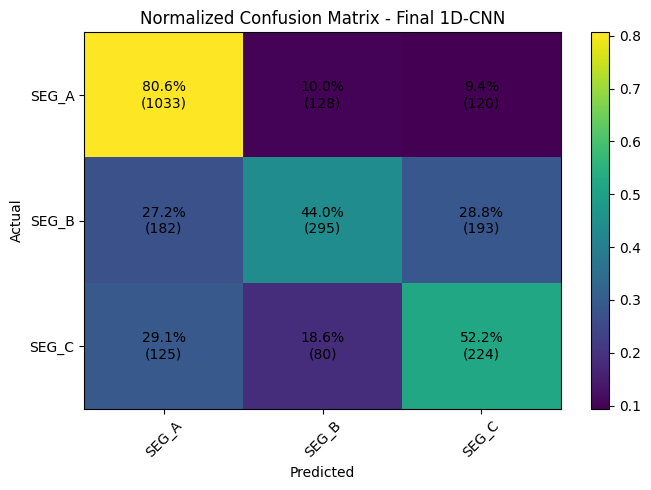

,SEG_A,SEG_B,SEG_C
SEG_A,1033,128,120
SEG_B,182,295,193
SEG_C,125,80,224


In [48]:
plot_confusion_matrix_with_percentages(
    y_true=y_true_final,
    y_pred=y_pred_final,
    target_names=target_names,
    normalize=True,
    title="Normalized Confusion Matrix - Final 1D-CNN"
)

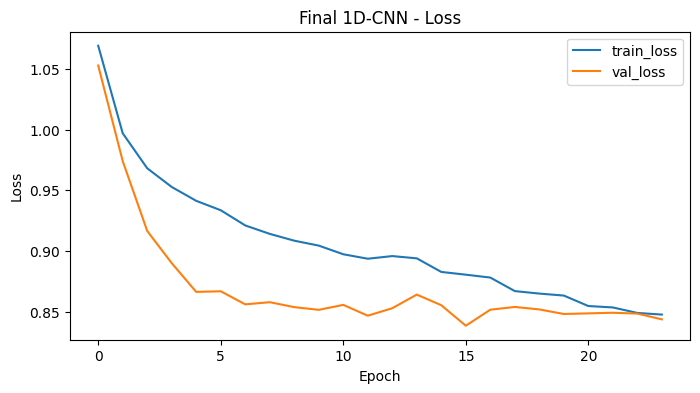

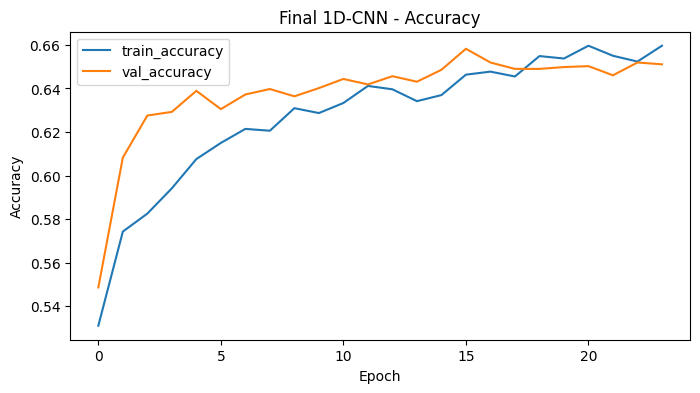

In [49]:
plot_history(history_final, "Final 1D-CNN")

In [50]:
from pathlib import Path

MODEL_DIR = Path("/Users/omarleosamman/Downloads/pfizer_models")
MODEL_DIR.mkdir(parents=True, exist_ok=True)

final_cnn.save(MODEL_DIR / "final_1d_cnn_atseg.keras")
predictions_df = pd.DataFrame({
    "y_true": y_true_final,
    "y_pred": y_pred_final,
    "pred_SEG_A_proba": proba_final[:, 0],
    "pred_SEG_B_proba": proba_final[:, 1],
    "pred_SEG_C_proba": proba_final[:, 2]
})

predictions_df.to_csv(MODEL_DIR / "final_test_predictions.csv", index=False)